# **customer churn prediction using machine learning**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Remove empty values
df = df.dropna()

# Drop customer ID (IMPORTANT)
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric (common fix)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

# Convert target column
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Convert categorical columns into numeric
df = pd.get_dummies(df)

# Features & target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Model
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

Accuracy: 0.7974971558589306
Confusion Matrix:
 [[1168  123]
 [ 233  234]]


# **BAR GRAPH**

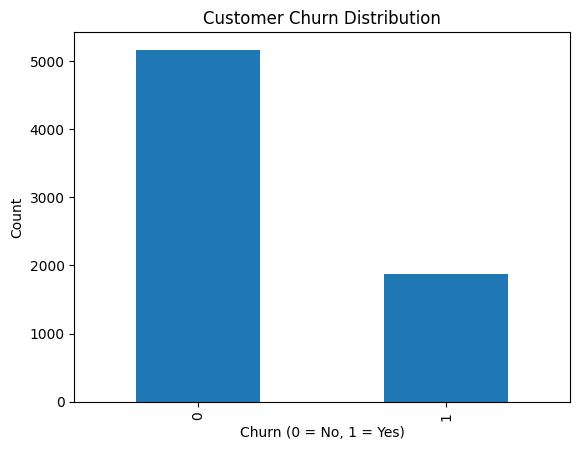

In [3]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# **pie chart**

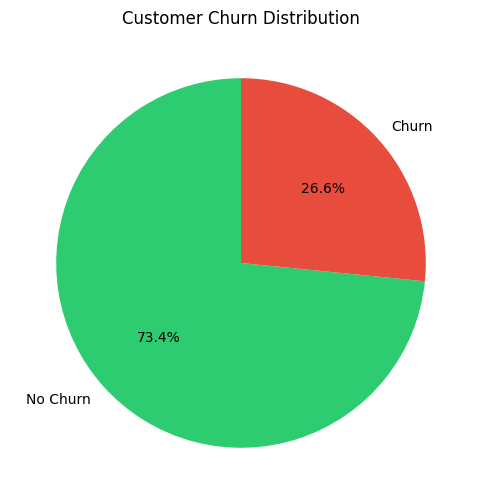

In [4]:
import matplotlib.pyplot as plt

counts = df["Churn"].value_counts()
labels = ["No Churn", "Churn"]
colors = ["#2ecc71", "#e74c3c"]

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Customer Churn Distribution")
plt.show()

# **Box plot**

/tmp/ipykernel_57/1847114224.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=["green", "red"])


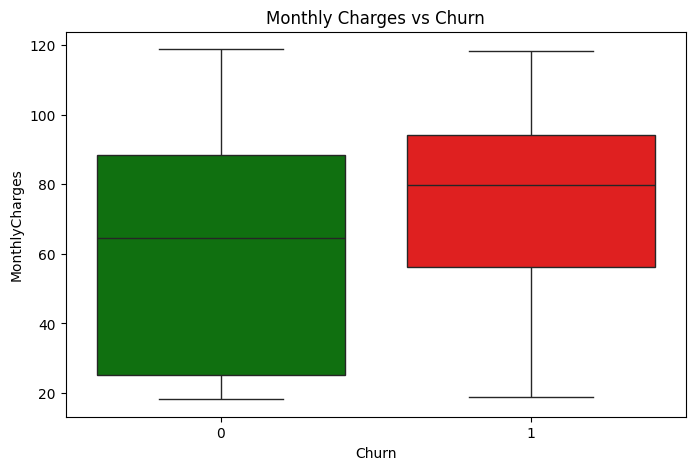

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette=["green", "red"])

plt.title("Monthly Charges vs Churn")
plt.show()

# **Methodology:**
The dataset was preprocessed by handling missing values, converting categorical variables into numerical form, and removing irrelevant columns such as customer ID. The target variable “Churn” was encoded into binary format.
# **Model:**
A Random Forest Classifier was used to predict customer churn.
# **Evaluation:**
The model was evaluated using accuracy score and confusion matrix.